In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

print("Libraries loaded successfully")

Libraries loaded successfully


In [4]:
df = pd.read_csv("train.csv")

print("Shape:", df.shape)
df.head()

Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
y = df["SalePrice"]
X = df.drop("SalePrice", axis=1)

print("Target shape:", y.shape)
print("Features shape:", X.shape)

Target shape: (1460,)
Features shape: (1460, 80)


In [6]:
# Drop columns with more than 40% missing values
missing_percent = X.isnull().mean()
cols_to_drop = missing_percent[missing_percent > 0.4].index

X = X.drop(cols_to_drop, axis=1)

print("Dropped columns:", len(cols_to_drop))
print("New shape:", X.shape)


Dropped columns: 6
New shape: (1460, 74)


In [9]:
for col in X.select_dtypes(include=["int64", "float64"]).columns:
    X[col] = X[col].fillna(X[col].median())

In [10]:
X = pd.get_dummies(X, drop_first=True)

print("After encoding shape:", X.shape)

After encoding shape: (1460, 230)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1168, 230)
Test shape: (292, 230)


In [12]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression RMSE:", lr_rmse)

Linear Regression RMSE: 52266.13594062163


In [13]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest RMSE:", rf_rmse)

Random Forest RMSE: 28873.365551584433


In [14]:
print("Linear Regression RMSE:", lr_rmse)
print("Random Forest RMSE:", rf_rmse)

if rf_rmse < lr_rmse:
    print("Random Forest performs better")
else:
    print("Linear Regression performs better")

Linear Regression RMSE: 52266.13594062163
Random Forest RMSE: 28873.365551584433
Random Forest performs better


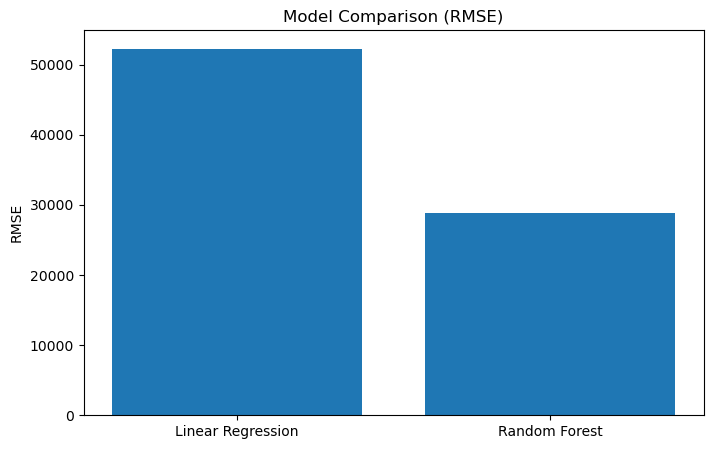

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

models = ["Linear Regression", "Random Forest"]
rmse_values = [lr_rmse, rf_rmse]

plt.bar(models, rmse_values)
plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE")
plt.show()

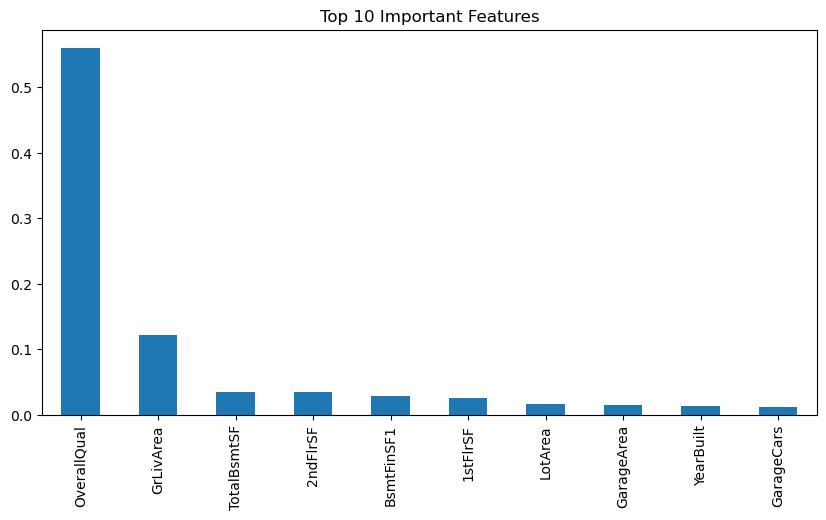

In [16]:
import pandas as pd

importances = rf.feature_importances_
feature_names = X.columns

feature_imp = pd.Series(importances, index=feature_names)
top_features = feature_imp.sort_values(ascending=False)[:10]

plt.figure(figsize=(10,5))
top_features.plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()